In [17]:
import numpy as np
import pandas as pd
from scipy.sparse import load_npz
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
from pathlib import Path
import re
import seaborn as sns

%matplotlib inline

## Configuration

In [2]:
# Use toy graph for faster prototyping
USE_TOY = True  # Set to False for full graph

# Paths
PROJECT_ROOT = Path('..')
output_dir = PROJECT_ROOT / 'figures'
output_dir.mkdir(exist_ok=True, parents=True)

print(f"Saving figures to {output_dir}")

if USE_TOY:
    GRAPH_DIR = PROJECT_ROOT / '1_genome_to_graph/graph_outputs/protein_graph_toy'
else:
    GRAPH_DIR = PROJECT_ROOT / '1_genome_to_graph/graph_outputs/protein_graph'

# K-mer data (always use full data)
KMER_DIR = PROJECT_ROOT / '1_genome_to_graph/intermediate/kmer/5mer'
KMER_MATRIX = KMER_DIR / '5mer_matrix.npz'
KMER_META = KMER_DIR / '5mer_matrix.meta.npz'

print(f"Using {'TOY' if USE_TOY else 'FULL'} graph")
print(f"Graph directory: {GRAPH_DIR}")

Saving figures to ../figures
Using TOY graph
Graph directory: ../1_genome_to_graph/graph_outputs/protein_graph_toy


# Load Genome K-mer Embeddings

In [26]:
def extract_taxonomy_from_ids(genome_ids):
    """
    Extract taxonomic information from RefSeq genome IDs.
    Format: GCF_XXXXXX.Y_Genus_species_strain
    """
    taxonomy = {}
    
    for gid in genome_ids:
        # Remove GCF prefix
        name_parts = gid.split('_', 2)
        if len(name_parts) >= 3:
            organism = name_parts[2]
            parts = organism.split('_')
            
            genus = parts[0] if len(parts) > 0 else 'Unknown'
            species = parts[1] if len(parts) > 1 else 'sp'
            
            # Clean up special characters
            genus = re.sub(r'[^a-zA-Z]', '', genus)
            species = re.sub(r'[^a-zA-Z]', '', species)
            
            taxonomy[gid] = {
                'genus': genus,
                'species': species,
                'full_name': f"{genus} {species}"
            }
        else:
            taxonomy[gid] = {
                'genus': 'Unknown',
                'species': 'sp',
                'full_name': 'Unknown sp'
            }
    
    return taxonomy

# Load k-mer matrix
print("Loading k-mer matrix...")
kmer_matrix = load_npz(KMER_MATRIX)
kmer_meta = np.load(KMER_META, allow_pickle=True)
genome_ids = kmer_meta['genome_ids']

print(f"K-mer matrix shape: {kmer_matrix.shape}")
print(f"Number of genomes: {len(genome_ids)}")
print(f"K-mer dimensionality: {kmer_matrix.shape[1]}")

# Extract taxonomy
print("\nExtracting taxonomy...")
taxonomy = extract_taxonomy_from_ids(genome_ids)
genome_taxonomy_df = pd.DataFrame([
    {'genome_id': gid, **taxonomy[gid]}
    for gid in genome_ids
])

print(f"Unique genera: {genome_taxonomy_df['genus'].nunique()}")
print(f"Unique species: {genome_taxonomy_df['full_name'].nunique()}")
# Extract accession number (GCF_XXXXXX.X) for matching with edges
# Edges use just the accession, but k-mer data has full organism names
genome_taxonomy_df['genome_accession'] = genome_taxonomy_df['genome_id'].str.extract(r'(GCF_\d+\.\d+)')[0]

print(f"\nExtracted {genome_taxonomy_df['genome_accession'].nunique()} unique accessions")
genome_taxonomy_df.head()

Loading k-mer matrix...
K-mer matrix shape: (7664, 512)
Number of genomes: 7664
K-mer dimensionality: 512

Extracting taxonomy...
Unique genera: 2140
Unique species: 7647

Extracted 7664 unique accessions


,genome_id,genus,species,full_name,genome_accession
0,GCF_000006985.1_Chlorobaculum_tepidum_TLS,Chlorobaculum,tepidum,Chlorobaculum tepidum,GCF_000006985.1
1,GCF_000007085.1_Caldanaerobacter_subterraneus_...,Caldanaerobacter,subterraneus,Caldanaerobacter subterraneus,GCF_000007085.1
2,GCF_000007485.1_Tropheryma_whipplei_str__Twist,Tropheryma,whipplei,Tropheryma whipplei,GCF_000007485.1
3,GCF_000007605.1_Chlamydia_caviae_GPIC,Chlamydia,caviae,Chlamydia caviae,GCF_000007605.1
4,GCF_000007745.1__Mannheimia__succiniciproducen...,,Mannheimia,Mannheimia,GCF_000007745.1


# Load Gene Cluster Embeddings

In [ ]:
# Load cluster embeddings (PCA-reduced for toy, full for production)
print("Loading gene cluster embeddings...")

if USE_TOY:
    # Toy graph has PCA-reduced embeddings
    emb_file = GRAPH_DIR / 'cluster_embeddings_pca50.npz'
    emb_data = np.load(emb_file)
    cluster_embeddings = emb_data['embeddings']  # (n_clusters, 50)
    cluster_ids = emb_data['cluster_ids']
else:
    # Full graph has full 1152D embeddings
    emb_file = GRAPH_DIR / 'cluster_embeddings.npz'
    emb_data = np.load(emb_file, allow_pickle=True)
    cluster_embeddings = emb_data['embeddings']  # (n_clusters, 1152)
    cluster_ids = emb_data['cluster_ids']

print(f"Cluster embeddings shape: {cluster_embeddings.shape}")
print(f"Number of clusters: {len(cluster_ids)}")

# Load cluster metadata
cluster_index = pd.read_csv(GRAPH_DIR / 'cluster_index.csv')
print(f"\nCluster metadata shape: {cluster_index.shape}")
cluster_index.head()

Loading gene cluster embeddings...
Cluster embeddings shape: (365211, 50)
Number of clusters: 365211

Cluster metadata shape: (365211, 3)


,cluster_id,genome_id,cluster_size
0,GCF_000006985.1_NC_002932.3_1061,GCF_000006985.1,11
1,GCF_000006985.1_NC_002932.3_1091,GCF_000006985.1,12
2,GCF_000006985.1_NC_002932.3_1196,GCF_000006985.1,12
3,GCF_000006985.1_NC_002932.3_1248,GCF_000006985.1,10
4,GCF_000006985.1_NC_002932.3_131,GCF_000006985.1,12


# Analyze genome-gene edges

In [15]:
genome_gene_edges['genome_id'].value_counts()

genome_id
GCF_035917195.1    7927
GCF_035918175.1    7549
GCF_016598615.1    7520
GCF_045162825.1    7414
GCF_003955715.1    7326
                   ... 
GCF_017656055.1      39
GCF_964031065.1      33
GCF_033370915.1      30
GCF_001274515.1      18
GCF_021057185.1       2
Name: count, Length: 7664, dtype: int64

In [27]:
genome_taxonomy_df = genome_taxonomy_df.set_index('genome_accession')
genome_taxonomy_df['gene_count'] = genome_gene_edges['genome_id'].value_counts()
genome_taxonomy_df

,genome_id,genus,species,full_name,gene_count
genome_accession,,,,,
GCF_000006985.1,GCF_000006985.1_Chlorobaculum_tepidum_TLS,Chlorobaculum,tepidum,Chlorobaculum tepidum,1289
GCF_000007085.1,GCF_000007085.1_Caldanaerobacter_subterraneus_...,Caldanaerobacter,subterraneus,Caldanaerobacter subterraneus,1660
GCF_000007485.1,GCF_000007485.1_Tropheryma_whipplei_str__Twist,Tropheryma,whipplei,Tropheryma whipplei,284
GCF_000007605.1,GCF_000007605.1_Chlamydia_caviae_GPIC,Chlamydia,caviae,Chlamydia caviae,820
GCF_000007745.1,GCF_000007745.1__Mannheimia__succiniciproducen...,,Mannheimia,Mannheimia,1750
...,...,...,...,...,...
GCF_965284585.1,GCF_965284585.1_Winogradskyella_ouciana,Winogradskyella,ouciana,Winogradskyella ouciana,2254
GCF_965284685.1,GCF_965284685.1_Sphingorhabdus_contaminans,Sphingorhabdus,contaminans,Sphingorhabdus contaminans,2057
GCF_965284695.1,GCF_965284695.1_Fluviicola_sp_,Fluviicola,sp,Fluviicola sp,1271


<Axes: xlabel='gene_count', ylabel='Count'>

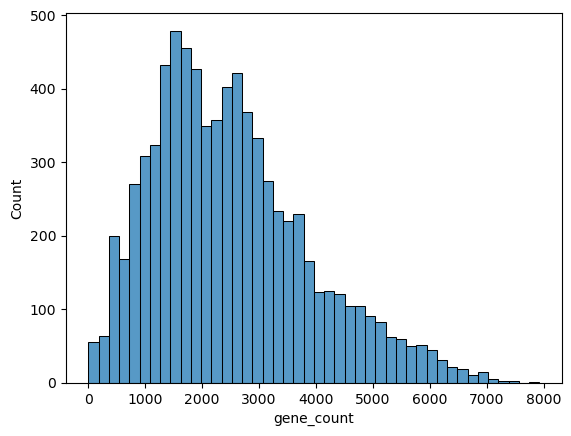

In [29]:
sns.histplot(data = genome_taxonomy_df, x = 'gene_count')

In [37]:
genome_taxonomy_df.value_counts('genus')['uncultured']

np.int64(7)

In [35]:
genome_taxonomy_df.groupby('genus').mean(['gene_count'])

,gene_count
genus,
,2354.513514
Abiotrophia,926.000000
Abyssalbus,2378.000000
Abyssibius,2170.000000
Abyssicoccus,993.000000
...,...
endosymbiont,372.000000
secondary,475.000000
symbiont,56.000000


# Plot Full Graph

### Compute Genome UMAP Embeddings

In [4]:
# Convert to dense
print("Converting k-mer matrix to dense...")
X_kmer = kmer_matrix.toarray()

# PCA first for speed
print("Running PCA (50 components)...")
pca_kmer = PCA(n_components=50, random_state=42)
X_kmer_pca = pca_kmer.fit_transform(X_kmer)
print(f"Explained variance: {pca_kmer.explained_variance_ratio_.sum():.3f}")

# UMAP
print("\nRunning UMAP on genome k-mers...")
genome_umap = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42,
    metric='euclidean'
)
genome_coords_2d = genome_umap.fit_transform(X_kmer_pca)

print(f"Genome UMAP coordinates shape: {genome_coords_2d.shape}")

# Add to dataframe
genome_taxonomy_df['umap_x'] = genome_coords_2d[:, 0]
genome_taxonomy_df['umap_y'] = genome_coords_2d[:, 1]


Converting k-mer matrix to dense...
Running PCA (50 components)...
Explained variance: 0.987

Running UMAP on genome k-mers...


/home/dmullane/micromamba/envs/default_jupyter/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Genome UMAP coordinates shape: (7664, 2)

Extracted 7664 unique accessions


,genome_id,genus,species,full_name,umap_x,umap_y,genome_accession
0,GCF_000006985.1_Chlorobaculum_tepidum_TLS,Chlorobaculum,tepidum,Chlorobaculum tepidum,6.907958,2.649068,GCF_000006985.1
1,GCF_000007085.1_Caldanaerobacter_subterraneus_...,Caldanaerobacter,subterraneus,Caldanaerobacter subterraneus,-2.326317,6.177191,GCF_000007085.1
2,GCF_000007485.1_Tropheryma_whipplei_str__Twist,Tropheryma,whipplei,Tropheryma whipplei,2.291158,2.473702,GCF_000007485.1
3,GCF_000007605.1_Chlamydia_caviae_GPIC,Chlamydia,caviae,Chlamydia caviae,-0.339288,3.359493,GCF_000007605.1
4,GCF_000007745.1__Mannheimia__succiniciproducen...,,Mannheimia,Mannheimia,-1.947132,-0.270652,GCF_000007745.1


### Compute Gene Cluster UMAP Embeddings

In [6]:
# If using full embeddings, run PCA first
if cluster_embeddings.shape[1] > 100:
    print("Running PCA on cluster embeddings (50 components)...")
    pca_cluster = PCA(n_components=50, random_state=42)
    cluster_embeddings_pca = pca_cluster.fit_transform(cluster_embeddings)
    print(f"Explained variance: {pca_cluster.explained_variance_ratio_.sum():.3f}")
else:
    cluster_embeddings_pca = cluster_embeddings
    print("Using pre-reduced embeddings")

# UMAP
print("\nRunning UMAP on gene clusters...")
cluster_umap = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42,
    metric='euclidean'
)
cluster_coords_2d = cluster_umap.fit_transform(cluster_embeddings_pca)

print(f"Cluster UMAP coordinates shape: {cluster_coords_2d.shape}")

# Add to dataframe
cluster_index['umap_x'] = cluster_coords_2d[:, 0]
cluster_index['umap_y'] = cluster_coords_2d[:, 1]

cluster_index.head()

Using pre-reduced embeddings

Running UMAP on gene clusters...


/home/dmullane/micromamba/envs/default_jupyter/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Cluster UMAP coordinates shape: (365211, 2)


,cluster_id,genome_id,cluster_size,umap_x,umap_y
0,GCF_000006985.1_NC_002932.3_1061,GCF_000006985.1,11,7.147488,10.897525
1,GCF_000006985.1_NC_002932.3_1091,GCF_000006985.1,12,11.471183,12.335750
2,GCF_000006985.1_NC_002932.3_1196,GCF_000006985.1,12,7.863253,10.881490
3,GCF_000006985.1_NC_002932.3_1248,GCF_000006985.1,10,11.386742,11.340624
4,GCF_000006985.1_NC_002932.3_131,GCF_000006985.1,12,10.895759,13.018236


### Load Genome-Gene Edges

In [7]:
# Load genome-gene edges
print("Loading genome-gene edges...")
genome_gene_edges = pd.read_csv(GRAPH_DIR / 'genome_gene_edges.csv')

print(f"Total edges: {len(genome_gene_edges):,}")
print(f"Unique genomes: {genome_gene_edges['genome_id'].nunique():,}")
print(f"Unique clusters: {genome_gene_edges['cluster_id'].nunique():,}")

genome_gene_edges.head()

Loading genome-gene edges...
Total edges: 19,196,625
Unique genomes: 7,664
Unique clusters: 365,211


,genome_id,cluster_id
0,GCF_002288505.1,GCF_000021685.1_NC_011959.1_1227
1,GCF_002288505.1,GCF_937425535.1_NZ_OW485601.1_858
2,GCF_002288505.1,GCF_004014695.1_NZ_CP034836.1_2762
3,GCF_002288505.1,GCF_009789655.1_NZ_CP046909.1_1354
4,GCF_002288505.1,GCF_000013385.1_NC_007760.1_1093


### Plotting Function

In [8]:
def plot_genome_gene_3d(genome_df, cluster_df, edges_df, highlight_genome=None, max_edges=1000):
    """
    Create 3D plot with genomes and genes separated in Z dimension.
    
    Args:
        genome_df: DataFrame with genome coordinates and metadata
        cluster_df: DataFrame with cluster coordinates and metadata
        edges_df: DataFrame with genome_id, cluster_id edges
        highlight_genome: Genome accession (e.g., GCF_000006985.1) to highlight (optional)
        max_edges: Maximum number of edges to plot (for performance)
    """
    fig = plt.figure(figsize=(16, 12))
    ax = fig.add_subplot(111, projection='3d')
    
    # Disable automatic z-ordering to allow manual control via zorder parameter
    ax.set_proj_type('persp', focal_length=0.2)
    if hasattr(ax, 'computed_zorder'):
        ax.computed_zorder = False
    
    # Z-levels
    genome_z = 1.0
    cluster_z = 0.0
    
    # Create lookup dictionaries for coordinates
    genome_coords = genome_df.set_index('genome_accession')[['umap_x', 'umap_y']].to_dict('index')
    cluster_coords = cluster_df.set_index('cluster_id')[['umap_x', 'umap_y']].to_dict('index')
    
    # Rendering order (bottom to top):
    # 1. Grey gene nodes (zorder=1)
    # 2. Connected gene nodes (zorder=2)
    # 3. Genome-gene edges (zorder=3)
    # 4. Grey genomes (zorder=4)
    # 5. Colored/highlighted genomes (zorder=5)
    
    # LAYER 1: Plot grey gene clusters (bottom)
    if highlight_genome:
        highlight_edges = edges_df[edges_df['genome_id'] == highlight_genome]
        connected_clusters = set(highlight_edges['cluster_id'])
        connected_mask = cluster_df['cluster_id'].isin(connected_clusters)
        other_mask = ~connected_mask
        
        ax.scatter(
            cluster_df.loc[other_mask, 'umap_x'],
            cluster_df.loc[other_mask, 'umap_y'],
            cluster_z,
            c='lightgray',
            s=10,
            alpha=0.2,
            # label='Other Gene Clusters',
            depthshade=False,
            zorder=1
        )
    else:
        scatter = ax.scatter(
            cluster_df['umap_x'],
            cluster_df['umap_y'],
            cluster_z,
            c=np.log10(cluster_df['cluster_size']),
            s=15,
            alpha=0.5,
            cmap='viridis',
            # label='Gene Clusters',
            depthshade=False,
            zorder=1
        )
        plt.colorbar(scatter, ax=ax, label='log10(Cluster Size)', pad=0.1)
    
    # LAYER 2: Plot connected gene clusters (if highlighting)
    if highlight_genome:
        genome_info = genome_df[genome_df['genome_accession'] == highlight_genome].iloc[0]
        ax.scatter(
            cluster_df.loc[connected_mask, 'umap_x'],
            cluster_df.loc[connected_mask, 'umap_y'],
            cluster_z,
            c='grey',
            s=15,
            alpha=0.75,
            edgecolors='black',
            linewidths=0.5,
            label=f"{genome_info['full_name']} genes: {len(connected_clusters)}",
            # label=f'Genes ({len(connected_clusters)})',
            depthshade=False,
            zorder=2
        )
    
    # LAYER 3: Plot edges
    if highlight_genome:
        print(f"Plotting {len(highlight_edges)} edges for genome {highlight_genome}")
        
        for _, edge in highlight_edges.iterrows():
            if edge['genome_id'] in genome_coords and edge['cluster_id'] in cluster_coords:
                g_coords = genome_coords[edge['genome_id']]
                c_coords = cluster_coords[edge['cluster_id']]
                
                ax.plot(
                    [g_coords['umap_x'], c_coords['umap_x']],
                    [g_coords['umap_y'], c_coords['umap_y']],
                    [genome_z, cluster_z],
                    'gray', alpha=0.1, linewidth=0.3,
                    zorder=3
                )
    else:
        if len(edges_df) > max_edges:
            edges_sample = edges_df.sample(max_edges, random_state=42)
            print(f"Sampling {max_edges} of {len(edges_df)} edges")
        else:
            edges_sample = edges_df
        
        for _, edge in edges_sample.iterrows():
            if edge['genome_id'] in genome_coords and edge['cluster_id'] in cluster_coords:
                g_coords = genome_coords[edge['genome_id']]
                c_coords = cluster_coords[edge['cluster_id']]
                
                ax.plot(
                    [g_coords['umap_x'], c_coords['umap_x']],
                    [g_coords['umap_y'], c_coords['umap_y']],
                    [genome_z, cluster_z],
                    'gray', alpha=0.1, linewidth=0.3,
                    zorder=3
                )
    
    # LAYER 4: Plot grey genomes
    if highlight_genome:
        highlight_mask = genome_df['genome_accession'] == highlight_genome
        other_mask = ~highlight_mask
        
        ax.scatter(
            genome_df.loc[other_mask, 'umap_x'],
            genome_df.loc[other_mask, 'umap_y'],
            genome_z,
            c='lightgray',
            s=20,
            alpha=0.3,
            # label='Other Genomes',
            depthshade=False,
            zorder=4
        )
    else:
        genus_counts = genome_df['genus'].value_counts()
        top_genera = genus_counts.head(15).index.tolist()
        top_mask = genome_df['genus'].isin(top_genera)
        other_mask = ~top_mask
        
        ax.scatter(
            genome_df.loc[other_mask, 'umap_x'],
            genome_df.loc[other_mask, 'umap_y'],
            genome_z,
            c='lightgray',
            s=20,
            alpha=0.3,
            label=f'Other Genera ({(~top_mask).sum()})',
            depthshade=False,
            zorder=4
        )
    
    # LAYER 5: Plot colored/highlighted genomes (top)
    if highlight_genome:
        genome_info = genome_df[genome_df['genome_accession'] == highlight_genome].iloc[0]
        ax.scatter(
            genome_df.loc[highlight_mask, 'umap_x'],
            genome_df.loc[highlight_mask, 'umap_y'],
            genome_z,
            c='black',
            s=40,
            marker="*",
            edgecolors='black',
            linewidths=1,
            label=f"{genome_info['full_name']} genome",
            depthshade=False,
            zorder=5
        )
    else:
        colors = plt.cm.tab20(np.linspace(0, 1, len(top_genera)))
        genus_colors = dict(zip(top_genera, colors))
        
        for genus in top_genera:
            mask = genome_df['genus'] == genus
            count = mask.sum()
            ax.scatter(
                genome_df.loc[mask, 'umap_x'],
                genome_df.loc[mask, 'umap_y'],
                genome_z,
                c=[genus_colors[genus]],
                s=30,
                alpha=0.7,
                label=f'{genus} ({count})',
                depthshade=False,
                zorder=5
            )
    
    # Labels and styling
    ax.set_xlabel('UMAP 1', fontsize=12, labelpad=10)
    ax.set_ylabel('UMAP 2', fontsize=12, labelpad=10)
    ax.set_zlabel('Layer', fontsize=12, labelpad=10)
    ax.set_zticks([cluster_z, genome_z])
    ax.set_zticklabels(['Genes', 'Genomes'])
    
    if highlight_genome:
        genome_info = genome_df[genome_df['genome_accession'] == highlight_genome].iloc[0]
        title = genome_info['full_name']
    else:
        title = f"Graph Representation of NCBI Refseq Prokaryotic\n{len(genome_df)} Genomes, {len(cluster_df)} Conserved Genes, {len(edges_df)} Genome-Gene edges"
    
    ax.set_title(title, fontsize=14, fontweight="bold", pad=20)
    ax.legend(loc='upper left', fontsize=8, framealpha=0.9, ncol=2)
    
    # Set viewing angle
    ax.view_init(elev=20, azim=45)
    
    plt.tight_layout()
    return fig, ax

### Plot a subsample of Edges

Sampling 2000 of 19196625 edges


/loc/scratch/43076876/ipykernel_10163/810434204.py:210: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


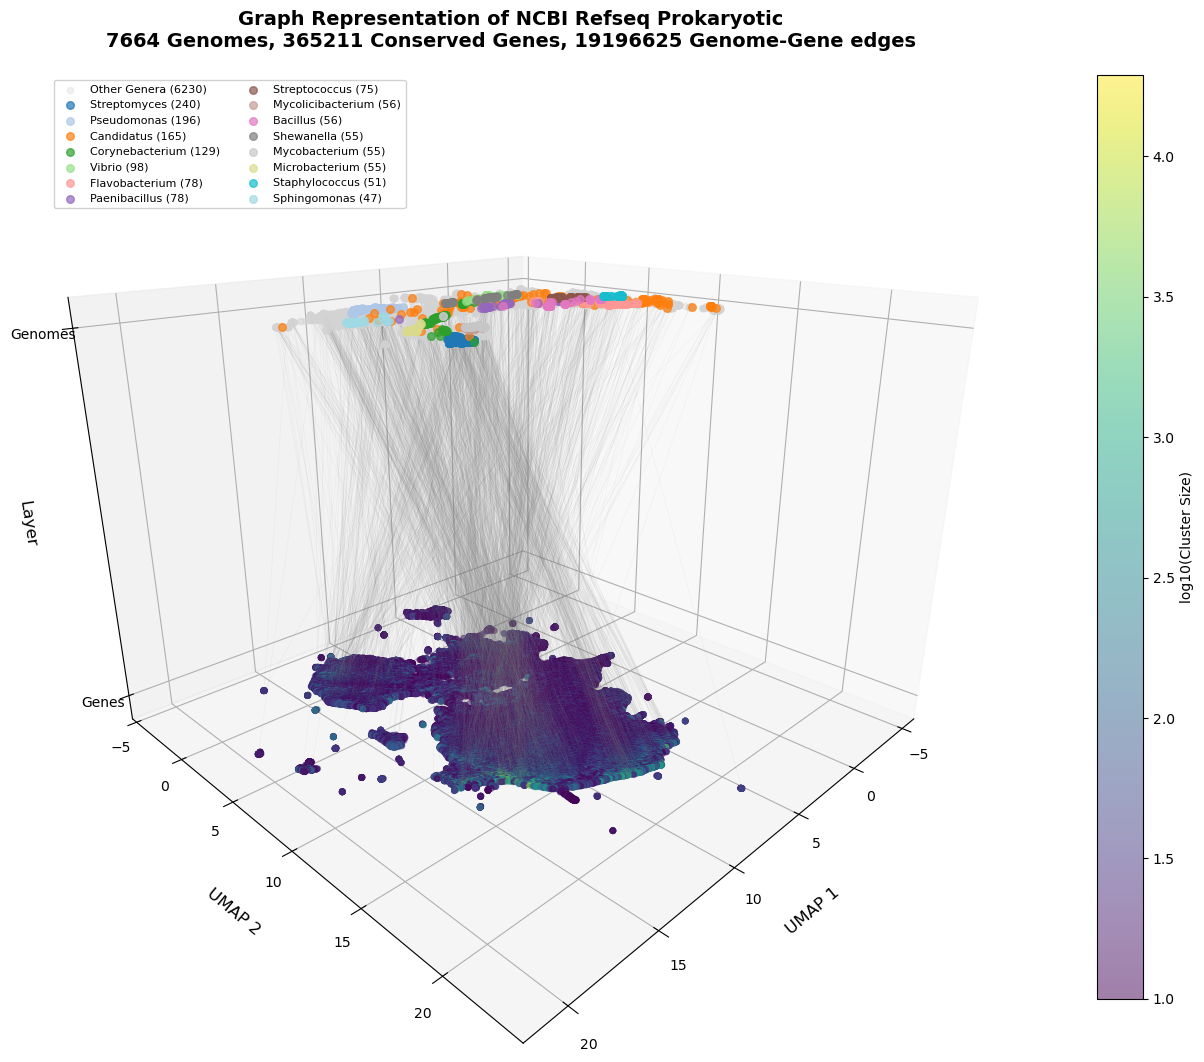

In [10]:
# Plot overall graph (sampled edges)
fig, ax = plot_genome_gene_3d(
    genome_taxonomy_df,
    cluster_index,
    genome_gene_edges,
    highlight_genome=None,
    max_edges=2000
)
fig.savefig(output_dir / 'genome_gene_3d_overall.png', dpi=300, bbox_inches='tight')
plt.show()

### Highlight Specific Genome

Highlighting genome: GCF_000006985.1
                                   genome_id          genus  species  \
0  GCF_000006985.1_Chlorobaculum_tepidum_TLS  Chlorobaculum  tepidum   

               full_name    umap_x    umap_y genome_accession  
0  Chlorobaculum tepidum  6.907958  2.649068  GCF_000006985.1  
Plotting 1289 edges for genome GCF_000006985.1


/loc/scratch/43076876/ipykernel_10163/810434204.py:210: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


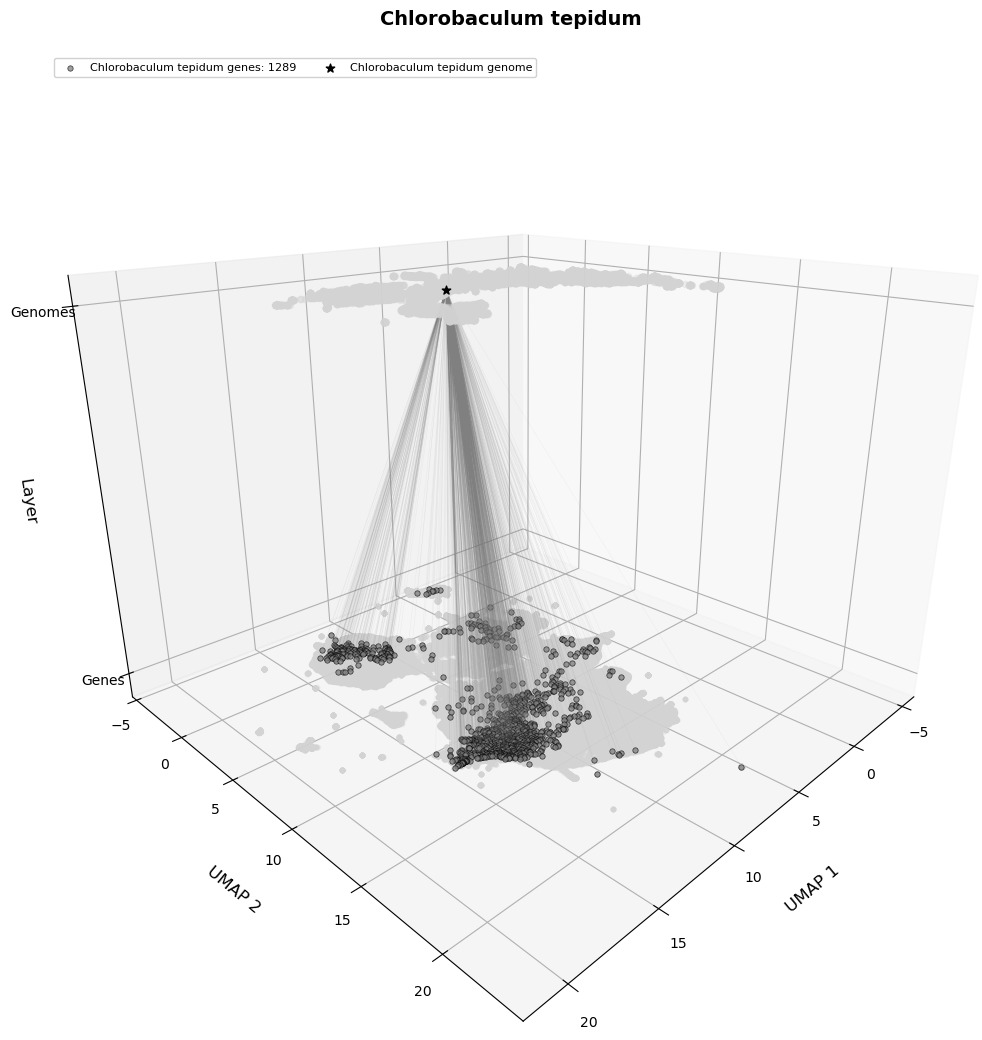

In [11]:
# Pick a random genome to highlight (use accession for matching with edges)
example_genome = genome_taxonomy_df['genome_accession'].iloc[0]
print(f"Highlighting genome: {example_genome}")
print(genome_taxonomy_df[genome_taxonomy_df['genome_accession'] == example_genome])

fig, ax = plot_genome_gene_3d(
    genome_taxonomy_df,
    cluster_index,
    genome_gene_edges,
    highlight_genome=example_genome
)
fig.savefig(output_dir / f'genome_gene_3d_{example_genome.replace(".", "_")}.png', dpi=300, bbox_inches='tight')
plt.show()
